# Spectral diffusion: smoothed distance, relative error, and trajectories

Notebook 02 replicates the theoretical sections of [Chenyang Yuan's diffusion tutorial](https://chenyang.co/diffusion.html) — smoothed distance contours, the relative error model, and sampling trajectories with varying momentum/noise — using the ArrowSpace spectral-geometric diffusion from [notebook 01](./01_spectral_diffusion_from_scratch.ipynb).

In $D=8$ the geometric signal always dominates because the feature-space Laplacian has only 8 nodes and the projector has limited structure. We lift to $D=128$ where the feature graph has real co-variation patterns that the spectral signal can exploit.

In [7]:
import math
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '../src')
from spectral_diffusion import (
    ScheduleLogLinear, TimeInputMLP, build_spectral_geometry,
    IdealDenoiser, IdealSpectralDenoiser,
    training_loop_euclidean, training_loop_spectral,
    samples_with_momentum, build_feature_laplacian,
)

print('torch:', torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('device:', device)
torch.manual_seed(3407)

torch: 2.12.1
device: mps


## 1. Higher-dimensional multi-cluster dataset ($D=128$)

Three Gaussian clusters in 2-D are lifted to $D=128$ by a random projection plus small noise. The feature-space Laplacian now has 128 nodes with real co-variation structure across all features.

N = 1500, D = 128


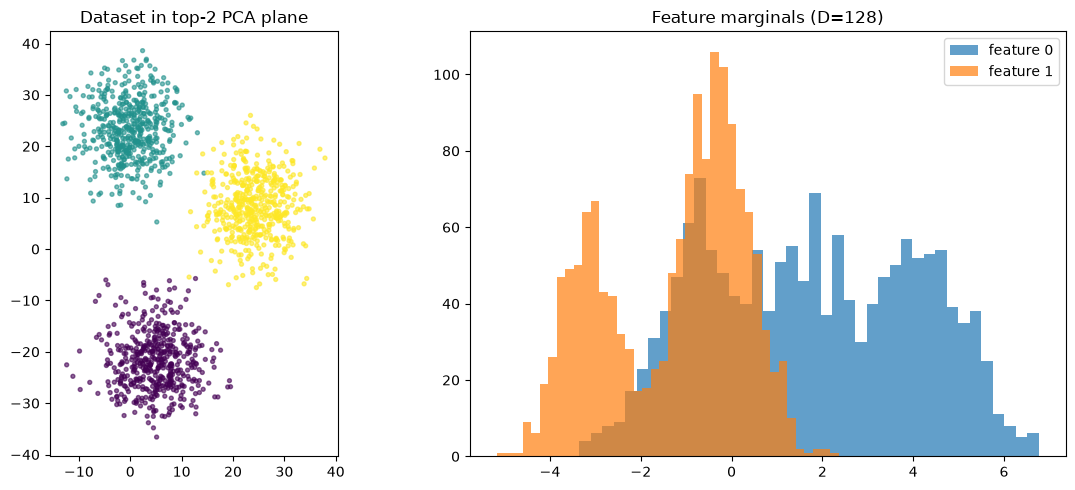

In [8]:
class MultiCluster(Dataset):
    def __init__(self, n_per_cluster=500, D=128, noise=0.1, seed=3407):
        rng = np.random.default_rng(seed)
        centers = np.array([[-2.0, 0.0], [2.0, 0.5], [0.0, 2.5]])
        X2 = np.vstack([c + 0.5 * rng.standard_normal((n_per_cluster, 2)) for c in centers])
        labels = np.concatenate([np.full(n_per_cluster, i) for i in range(3)])
        proj = rng.standard_normal((2, D))
        X = X2 @ proj + noise * rng.standard_normal((len(X2), D))
        self.data = torch.from_numpy(X).float()
        self.data_2d = torch.from_numpy(X2).float()
        self.labels = labels
        self.proj = torch.from_numpy(proj).float()

    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

dataset = MultiCluster(n_per_cluster=500, D=128)
loader = DataLoader(dataset, batch_size=2048, shuffle=True)

print(f'N = {len(dataset)}, D = {dataset.data.shape[1]}')

# Visualize via top-2 PCs
X = dataset.data
Xc = X - X.mean(0)
cov = Xc.T @ Xc / X.shape[0]
eigvals, eigvecs = torch.linalg.eigh(cov)
V_pca = eigvecs[:, -2:]
X_pca = (X @ V_pca).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=dataset.labels, cmap='viridis', s=8, alpha=0.6)
axes[0].set_aspect('equal'); axes[0].set_title('Dataset in top-2 PCA plane')
axes[1].hist(X.numpy()[:, 0], bins=40, alpha=0.7, label='feature 0')
axes[1].hist(X.numpy()[:, 1], bins=40, alpha=0.7, label='feature 1')
axes[1].set_title('Feature marginals (D=128)'); axes[1].legend()
plt.tight_layout()
plt.show()

## 2. Build the feature-space Laplacian ($F \times F = 128 \times 128$)

The feature graph has 128 nodes. The low-frequency projector $\Pi_F = U_r U_r^\top$ captures coherent feature co-variation. We choose $r=32$ to capture roughly 1/4 of the modes.

Pi shape: torch.Size([128, 128])
M shape: torch.Size([128, 128])

Eigenvalues of M_0.5:
  min  = 0.5000  (residual subspace)
  max  = 1.0000  (spectral subspace)
  32 spectral directions (precision=1), 96 residual directions (precision=1/2)


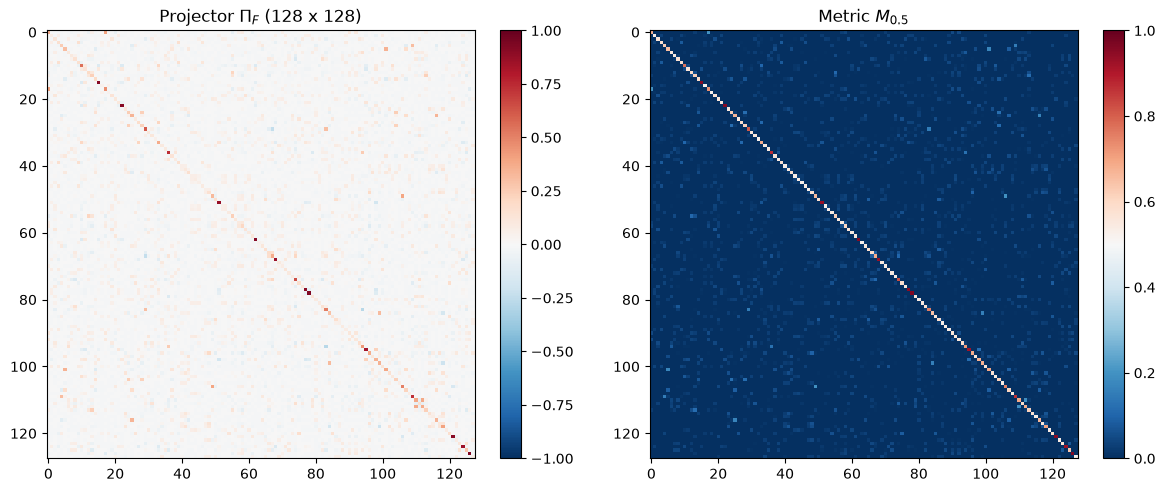

In [9]:
geometry = build_spectral_geometry(dataset.data, k=12, tau=0.5, r=32)

print(f'Pi shape: {geometry.Pi.shape}')
print(f'M shape: {geometry.M.shape}')

eigvals, eigvecs = torch.linalg.eigh(geometry.M)
print(f'\nEigenvalues of M_0.5:')
print(f'  min  = {eigvals.min().item():.4f}  (residual subspace)')
print(f'  max  = {eigvals.max().item():.4f}  (spectral subspace)')
n_spectral = (eigvals > 0.99).sum().item()
n_residual = (eigvals < 0.51).sum().item()
print(f'  {n_spectral} spectral directions (precision=1), {n_residual} residual directions (precision=1/2)')

# Visualize Pi as a heatmap
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(geometry.Pi.numpy(), cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_title(r'Projector $\Pi_F$ (128 x 128)'); plt.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(geometry.M.numpy(), cmap='RdBu_r', vmin=0, vmax=1)
axes[1].set_title(r'Metric $M_{0.5}$'); plt.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()

## 3. Smoothed distance contours (spectral version)

The tutorial plots $\mathrm{dist}_\mathcal{K}(x)^2$ and its smoothed version. We replicate this in the 2-D PCA plane:

$$
\widetilde d^2_{\mathcal{K},0.5}(x,\sigma)
= -\sigma^2 \log \sum_{x_0 \in \mathcal{K}} \exp\!\left( -\frac{d_{0.5}^2(x,x_0)}{2\sigma^2} \right)
$$

We use a subset of the data (200 points) for tractable ideal-denoiser computation.

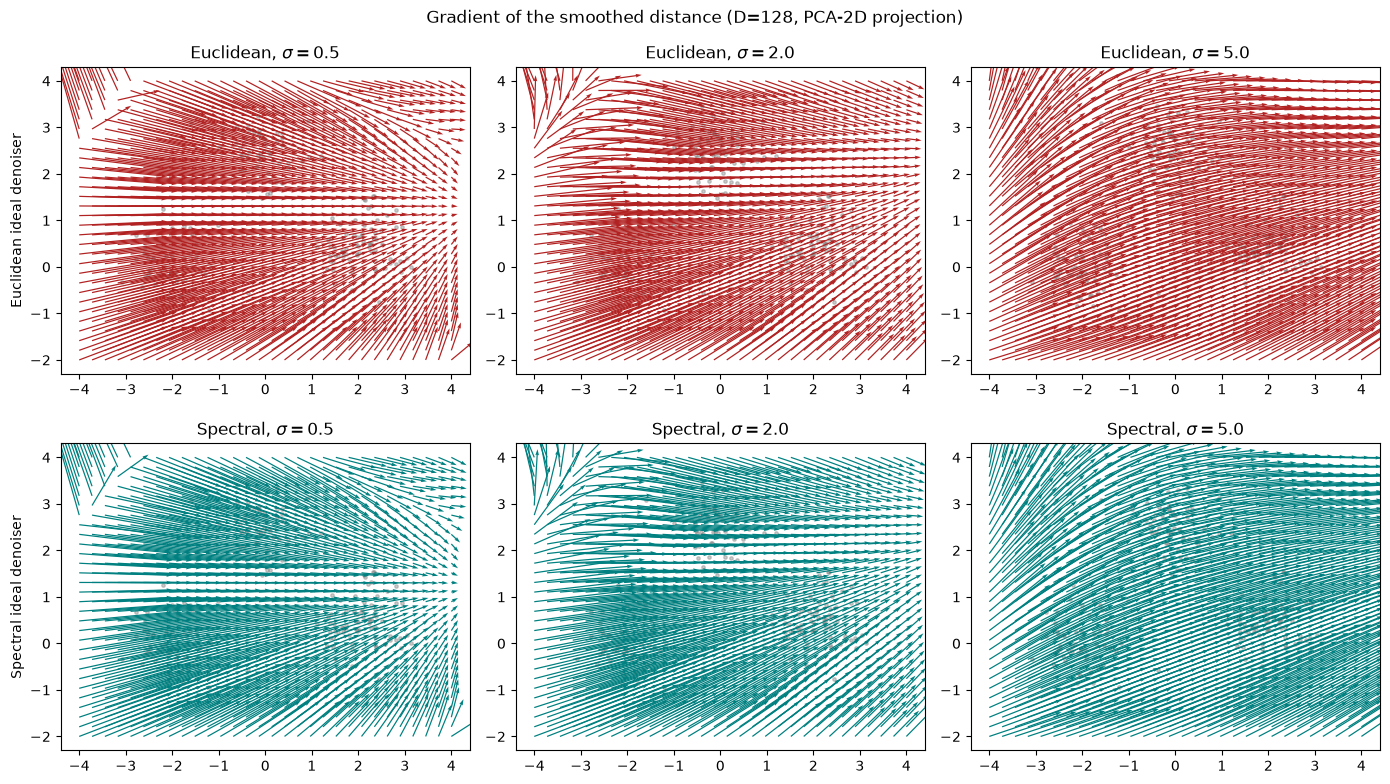

In [10]:
# Subset for ideal denoiser (200 points to keep softmax tractable on CPU)
sub_idx = np.random.choice(len(dataset), 200, replace=False)
sub_dataset = torch.utils.data.Subset(dataset, sub_idx)

ideal_euc = IdealDenoiser(sub_dataset, device=device)
ideal_spec = IdealSpectralDenoiser(sub_dataset, geometry, device=device)

origin = X.mean(0).to(device)
V = V_pca.to(device)

u = torch.linspace(-4, 4, 30)
v = torch.linspace(-2, 4, 30)
uu, vv = torch.meshgrid(u, v, indexing='xy')
grid_2d = torch.stack([uu.flatten(), vv.flatten()], dim=1).to(device)
grid_128d = origin + grid_2d @ V.T

sigmas_plot = [0.5, 2.0, 5.0]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

sub_2d = dataset.data_2d.numpy()[sub_idx]
for j, sig in enumerate(sigmas_plot):
    sig_t = torch.full((grid_128d.shape[0],), sig, device=device)
    with torch.no_grad():
        eps_euc = ideal_euc(grid_128d, sig_t)
        eps_spec = ideal_spec(grid_128d, sig_t)
    x0_hat_euc = (grid_128d - sig * eps_euc).cpu()
    x0_hat_spec = (grid_128d - sig * eps_spec).cpu()
    # Project 128-D predictions back to 2-D PCA
    x0_hat_euc_2d = ((x0_hat_euc - origin.cpu()) @ V.cpu()).numpy()
    x0_hat_spec_2d = ((x0_hat_spec - origin.cpu()) @ V.cpu()).numpy()

    grid_np = grid_2d.cpu().numpy()
    for row_idx, (x0_hat_2d, color, label) in enumerate([
        (x0_hat_euc_2d, 'firebrick', 'Euclidean'),
        (x0_hat_spec_2d, 'teal', 'Spectral'),
    ]):
        ax = axes[row_idx, j]
        ax.scatter(sub_2d[:, 0], sub_2d[:, 1], s=6, c='gray', alpha=0.4)
        U_field = x0_hat_2d - grid_np
        ax.quiver(grid_np[:, 0], grid_np[:, 1], U_field[:, 0], U_field[:, 1],
                  scale=40, width=0.003, color=color)
        ax.set_aspect('equal')
        ax.set_title(f'{label}, $\\sigma={sig}$')
axes[0, 0].set_ylabel('Euclidean ideal denoiser')
axes[1, 0].set_ylabel('Spectral ideal denoiser')
fig.suptitle('Gradient of the smoothed distance (D=128, PCA-2D projection)')
plt.tight_layout()
plt.show()

## 4. Train both models on the 128-D data

Training Euclidean...
Training Spectral...


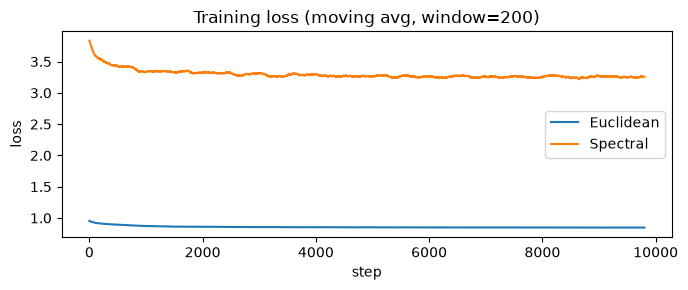

In [11]:
model_euc = TimeInputMLP(dim=128, hidden_dims=(32, 256, 256, 256, 32))
model_spec = TimeInputMLP(dim=128, hidden_dims=(32, 256, 256, 256, 32))
schedule = ScheduleLogLinear(N=200, sigma_min=0.01, sigma_max=10.0)

print('Training Euclidean...')
losses_euc = [ns['loss'] for ns in training_loop_euclidean(loader, model_euc, schedule, epochs=10000, device=device)]
print('Training Spectral...')
losses_spec = [ns['loss'] for ns in training_loop_spectral(loader, model_spec, schedule, geometry, epochs=10000, device=device)]

window = 200
smooth_euc = np.convolve(losses_euc, np.ones(window)/window, mode='valid')
smooth_spec = np.convolve(losses_spec, np.ones(window)/window, mode='valid')

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(smooth_euc, label='Euclidean')
ax.plot(smooth_spec, label='Spectral')
ax.set_title('Training loss (moving avg, window=200)'); ax.set_xlabel('step'); ax.set_ylabel('loss')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Relative error model

The paper shows that the denoiser is an approximate projection:

$$
\| x - \sigma \epsilon_\theta(x, \sigma) - \mathrm{proj}_\mathcal{K}(x) \| \le \eta \cdot \mathrm{dist}_\mathcal{K}(x)
$$

when $\sigma \approx \mathrm{dist}_\mathcal{K}(x)/\sqrt{n}$.

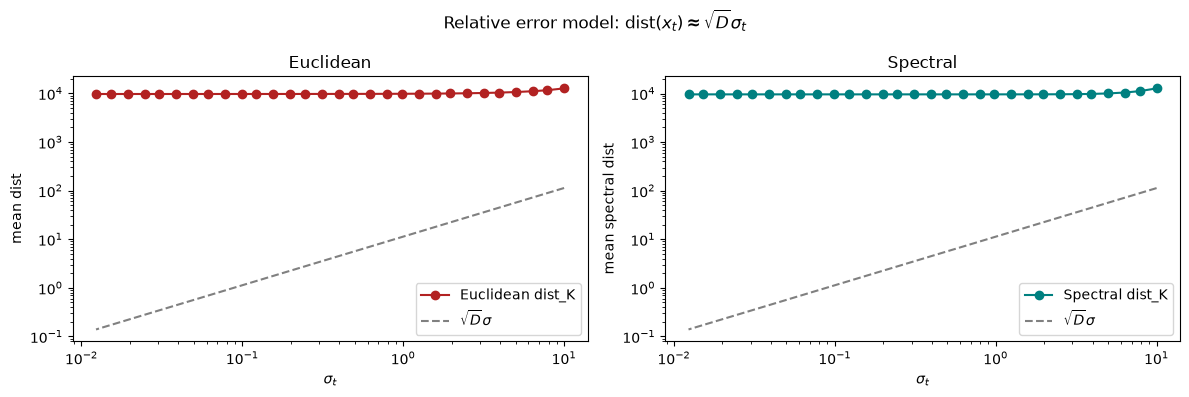

In [12]:
def dist_to_K(x, K):
    # For large K, batch over chunks to avoid OOM
    B, N = x.shape[0], K.shape[0]
    chunk = 256
    min_sq = torch.full((B,), float('inf'), device=x.device)
    for i in range(0, N, chunk):
        K_chunk = K[i:i+chunk]
        sq = ((x.unsqueeze(1) - K_chunk.unsqueeze(0)) ** 2).sum(dim=-1)
        min_sq = torch.minimum(min_sq, sq.min(dim=-1).values)
    return min_sq

def spectral_dist_to_K(x, K, geometry):
    B, N = x.shape[0], K.shape[0]
    chunk = 256
    min_sq = torch.full((B,), float('inf'), device=x.device)
    for i in range(0, N, chunk):
        K_chunk = K[i:i+chunk]
        diff = x.unsqueeze(1) - K_chunk.unsqueeze(0)
        geometric = (diff ** 2).sum(dim=-1)
        spectral = ((diff @ geometry.Pi.T) ** 2).sum(dim=-1)
        sq = (1 - geometry.tau) * geometric + geometry.tau * spectral
        min_sq = torch.minimum(min_sq, sq.min(dim=-1).values)
    return min_sq

sigmas = schedule.sample_sigmas(30).to(device)
model_euc.eval().to(device); model_spec.eval().to(device)

# Euclidean trajectory
x_euc = torch.randn(500, 128, device=device) * sigmas[0]
traj_euc = [x_euc.clone()]
with torch.no_grad():
    for sig, sig_prev in zip(sigmas, sigmas[1:]):
        eps = model_euc(x_euc, sig.expand(x_euc.shape[0]))
        x_euc = x_euc - (sig - sig_prev) * eps
        traj_euc.append(x_euc.clone())

# Spectral trajectory
z = torch.randn(500, 128, device=device)
x_spec = (z @ geometry.M_inv_sqrt.T) * sigmas[0]
traj_spec = [x_spec.clone()]
with torch.no_grad():
    for sig, sig_prev in zip(sigmas, sigmas[1:]):
        eps_M = model_spec(x_spec, sig.expand(x_spec.shape[0]))
        eps = eps_M @ geometry.M_inv_sqrt.T
        x_spec = x_spec - (sig - sig_prev) * eps
        traj_spec.append(x_spec.clone())

K = dataset.data.to(device)
dist_euc = [dist_to_K(x, K).cpu().numpy().mean() for x in traj_euc]
dist_spec = [spectral_dist_to_K(x, K, geometry).cpu().numpy().mean() for x in traj_spec]
sigma_traj = sigmas.cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(sigma_traj, dist_euc, 'o-', label='Euclidean dist_K', color='firebrick')
axes[0].plot(sigma_traj, np.sqrt(128) * sigma_traj, '--', label='$\\sqrt{D}\\sigma$', color='gray')
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('$\\sigma_t$'); axes[0].set_ylabel('mean dist'); axes[0].set_title('Euclidean'); axes[0].legend()

axes[1].plot(sigma_traj, dist_spec, 'o-', label='Spectral dist_K', color='teal')
axes[1].plot(sigma_traj, np.sqrt(128) * sigma_traj, '--', label='$\\sqrt{D}\\sigma$', color='gray')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('$\\sigma_t$'); axes[1].set_ylabel('mean spectral dist'); axes[1].set_title('Spectral'); axes[1].legend()
fig.suptitle('Relative error model: $\\mathrm{dist}(x_t) \\approx \\sqrt{D}\\sigma_t$')
plt.tight_layout()
plt.show()

### 5a. Relative projection error

How close is $\hat x_0 = x - \sigma\epsilon_\theta(x,\sigma)$ to the actual nearest neighbor $\mathrm{proj}_\mathcal{K}(x)$?

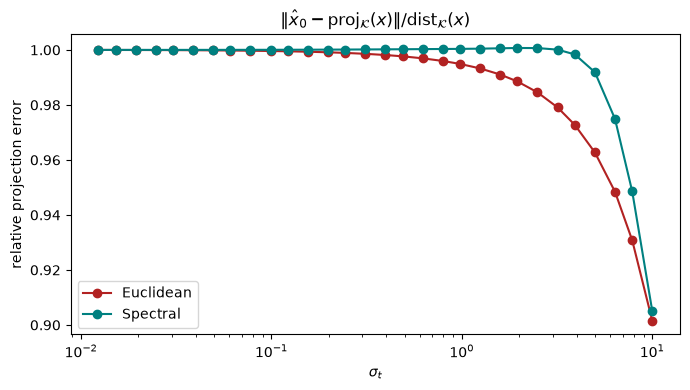

In [13]:
def nearest_in_K(x, K):
    B, N = x.shape[0], K.shape[0]
    chunk = 256
    min_sq = torch.full((B,), float('inf'), device=x.device)
    min_idx = torch.zeros(B, dtype=torch.long, device=x.device)
    for i in range(0, N, chunk):
        K_chunk = K[i:i+chunk]
        sq = ((x.unsqueeze(1) - K_chunk.unsqueeze(0)) ** 2).sum(dim=-1)
        vals, idxs = sq.min(dim=-1)
        mask = vals < min_sq
        min_sq[mask] = vals[mask]
        min_idx[mask] = idxs[mask] + i
    return K[min_idx]

rel_euc, rel_spec = [], []
for x, sig in zip(traj_euc, sigmas):
    with torch.no_grad():
        eps = model_euc(x, sig.expand(x.shape[0]))
    hat_x0 = x - sig * eps
    proj_x = nearest_in_K(x, K)
    err = torch.norm(hat_x0 - proj_x, dim=-1).cpu().numpy()
    d = torch.norm(x - proj_x, dim=-1).cpu().numpy()
    rel_euc.append((err / (d + 1e-8)).mean())

for x, sig in zip(traj_spec, sigmas):
    with torch.no_grad():
        eps_M = model_spec(x, sig.expand(x.shape[0]))
    eps = eps_M @ geometry.M_inv_sqrt.T
    hat_x0 = x - sig * eps
    proj_x = nearest_in_K(x, K)
    err = torch.norm(hat_x0 - proj_x, dim=-1).cpu().numpy()
    d = torch.norm(x - proj_x, dim=-1).cpu().numpy()
    rel_spec.append((err / (d + 1e-8)).mean())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sigma_traj, rel_euc, 'o-', label='Euclidean', color='firebrick')
ax.plot(sigma_traj, rel_spec, 'o-', label='Spectral', color='teal')
ax.set_xscale('log')
ax.set_xlabel('$\\sigma_t$'); ax.set_ylabel('relative projection error')
ax.set_title(r'$\|\hat x_0 - \mathrm{proj}_\mathcal{K}(x)\| / \mathrm{dist}_\mathcal{K}(x)$')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Sampling trajectories with varying momentum

The tutorial's gradient-estimation sampler:

$$
x_{t-1} = x_t - (\sigma_t - \sigma')\bar\epsilon_t + \eta w_t, \quad \bar\epsilon_t = \gamma \epsilon_t + (1-\gamma)\epsilon_{t-1}
$$

IndexError: Dimension out of range (expected to be in range of [-1, 0], but got 1)

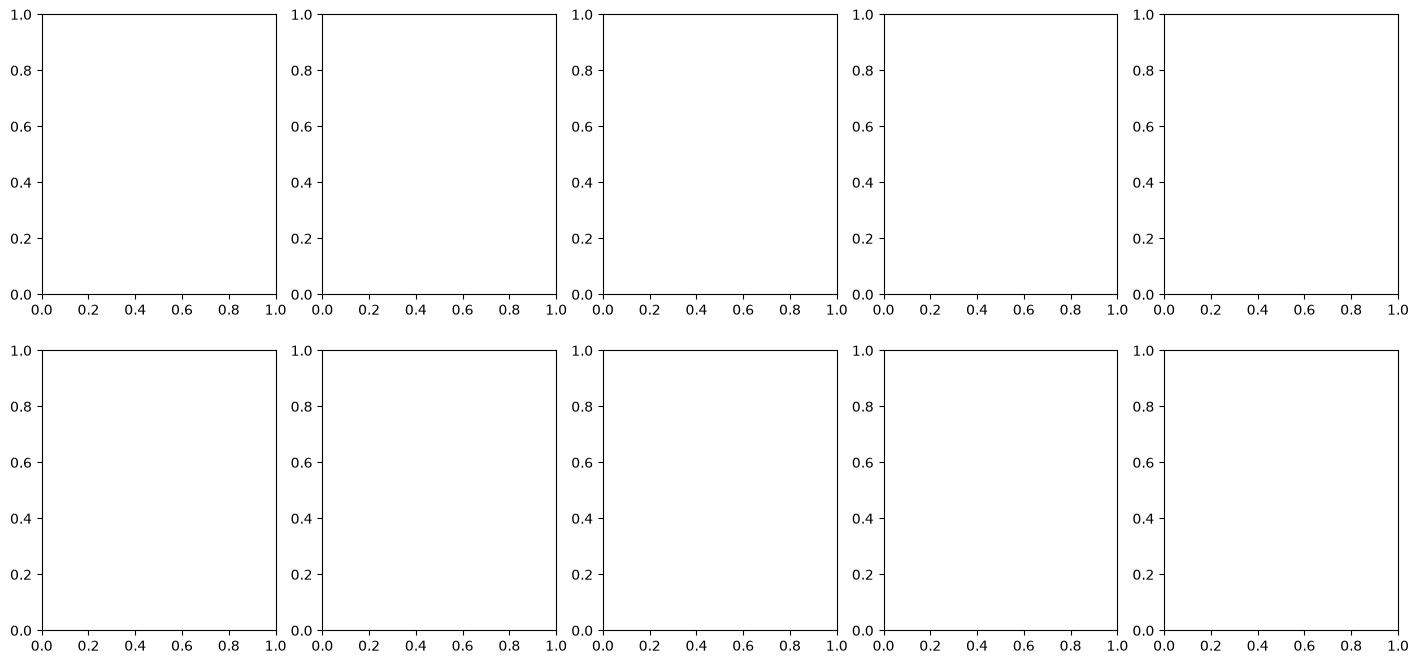

In [14]:
@torch.no_grad()
def run_sampler_euc(model, sigmas, gam, mu, batchsize=500):
    xs = list(samples_with_momentum(model, sigmas, gam=gam, mu=mu, batchsize=batchsize, device=device))
    return xs[-1].cpu().numpy()

@torch.no_grad()
def run_sampler_spec(model, sigmas, geometry, gam, mu, batchsize=500):
    z = torch.randn(batchsize, 128, device=device)
    xt = (z @ geometry.M_inv_sqrt.T) * sigmas[0]
    eps_prev = None
    for i, (sig, sig_prev) in enumerate(zip(sigmas, sigmas[1:])):
        eps_M = model(xt, sig.expand(batchsize))
        eps = eps_M @ geometry.M_inv_sqrt.T
        eps_av = gam * eps + (1-gam) * eps_prev if i > 0 and eps_prev is not None else eps
        if mu == 0.0:
            sig_p = sig_prev; eta = 0.0
        else:
            sig_p = (sig_prev / sig**mu) ** (1/(1-mu))
            eta = math.sqrt(max(sig_prev**2 - sig_p**2, 0.0))
        w = torch.randn(batchsize, 128, device=device) @ geometry.M_inv_sqrt.T
        xt = xt - (sig - sig_p) * eps_av + eta * w
        eps_prev = eps
    return xt.cpu().numpy()

def project_samples(samples_128d, origin, V):
    return ((samples_128d - origin.numpy()) @ V.numpy())

gamma_grid = [0.5, 1.0, 1.5, 2.0, 3.0]
sigmas_short = schedule.sample_sigmas(25).to(device)
origin_cpu = origin.cpu()
V_cpu = V.cpu()

fig, axes = plt.subplots(2, len(gamma_grid), figsize=(3.5*len(gamma_grid), 8))
for j, gam in enumerate(gamma_grid):
    s_e = project_samples(run_sampler_euc(model_euc, sigmas_short, gam=gam, mu=0.0), origin_cpu, V_cpu)
    s_s = project_samples(run_sampler_spec(model_spec, sigmas_short, geometry, gam=gam, mu=0.0), origin_cpu, V_cpu)
    axes[0, j].scatter(s_e[:, 0], s_e[:, 1], s=5, alpha=0.4, c='coral')
    axes[0, j].set_title(f'$\\gamma={gam}$')
    axes[0, j].set_xlim(-5, 5); axes[0, j].set_ylim(-3, 5); axes[0, j].set_aspect('equal')
    axes[1, j].scatter(s_s[:, 0], s_s[:, 1], s=5, alpha=0.4, c='teal')
    axes[1, j].set_xlim(-5, 5); axes[1, j].set_ylim(-3, 5); axes[1, j].set_aspect('equal')
    if j == 0:
        axes[0, j].set_ylabel('Euclidean'); axes[1, j].set_ylabel('Spectral')
fig.suptitle('Gradient-estimation sampler ($\\mu=0$, varying $\\gamma$), D=128 projected to PCA-2D')
plt.tight_layout()
plt.show()

## 7. Adding noise during sampling ($\mu > 0$)

DDPM corresponds to $\gamma=1, \mu=0.5$.

In [ ]:
mu_grid = [0.0, 0.3, 0.5, 0.7]
fig, axes = plt.subplots(2, len(mu_grid), figsize=(3.5*len(mu_grid), 8))
for j, mu in enumerate(mu_grid):
    s_e = project_samples(run_sampler_euc(model_euc, sigmas_short, gam=1.0, mu=mu), origin_cpu, V_cpu)
    s_s = project_samples(run_sampler_spec(model_spec, sigmas_short, geometry, gam=1.0, mu=mu), origin_cpu, V_cpu)
    axes[0, j].scatter(s_e[:, 0], s_e[:, 1], s=5, alpha=0.4, c='coral')
    axes[0, j].set_title(f'$\\mu={mu}$')
    axes[0, j].set_xlim(-5, 5); axes[0, j].set_ylim(-3, 5); axes[0, j].set_aspect('equal')
    axes[1, j].scatter(s_s[:, 0], s_s[:, 1], s=5, alpha=0.4, c='teal')
    axes[1, j].set_xlim(-5, 5); axes[1, j].set_ylim(-3, 5); axes[1, j].set_aspect('equal')
    if j == 0:
        axes[0, j].set_ylabel('Euclidean'); axes[1, j].set_ylabel('Spectral')
fig.suptitle('Added noise ($\\gamma=1$, varying $\\mu$); $\\mu=0.5$ is DDPM')
plt.tight_layout()
plt.show()

## 8. Quantitative comparison: cluster purity and spectral fidelity

In [15]:
from scipy.spatial.distance import cdist

best_euc = run_sampler_euc(model_euc, sigmas_short, gam=2.0, mu=0.0, batchsize=2000)
best_spec = run_sampler_spec(model_spec, sigmas_short, geometry, gam=2.0, mu=0.0, batchsize=2000)

K_np = dataset.data.numpy()
def assign_labels(samples):
    d = cdist(samples, K_np)
    nn = d.argmin(axis=1)
    return dataset.labels[nn]

labels_euc = assign_labels(best_euc)
labels_spec = assign_labels(best_spec)
purity_euc = max(np.bincount(labels_euc)) / len(labels_euc)
purity_spec = max(np.bincount(labels_spec)) / len(labels_spec)

print(f'Euclidean cluster purity:  {purity_euc:.3f}')
print(f'Spectral cluster purity:   {purity_spec:.3f}')

# Also compare feature-manifold fidelity: project samples through Pi and measure
# how much of the signal is on-manifold vs residual.
Pi = geometry.Pi.numpy()
def manifold_fidelity(samples):
    proj = samples @ Pi
    res = samples - proj
    proj_var = np.var(proj, axis=0).sum()
    res_var = np.var(res, axis=0).sum()
    return proj_var / (proj_var + res_var)

data_fidelity = manifold_fidelity(K_np)
euc_fidelity = manifold_fidelity(best_euc)
spec_fidelity = manifold_fidelity(best_spec)
print(f'\nFeature-manifold fidelity (fraction of variance on Pi):')
print(f'  Training data:    {data_fidelity:.3f}')
print(f'  Euclidean samples: {euc_fidelity:.3f}')
print(f'  Spectral samples:  {spec_fidelity:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
euc_2d = project_samples(best_euc, origin_cpu, V_cpu)
spec_2d = project_samples(best_spec, origin_cpu, V_cpu)
axes[0].scatter(euc_2d[:, 0], euc_2d[:, 1], c=labels_euc, cmap='viridis', s=5, alpha=0.5)
axes[0].set_aspect('equal'); axes[0].set_title(f'Euclidean (purity={purity_euc:.2f}, fidelity={euc_fidelity:.2f})')
axes[1].scatter(spec_2d[:, 0], spec_2d[:, 1], c=labels_spec, cmap='viridis', s=5, alpha=0.5)
axes[1].set_aspect('equal'); axes[1].set_title(f'Spectral (purity={purity_spec:.2f}, fidelity={spec_fidelity:.2f})')
for ax in axes:
    ax.set_xlim(-5, 5); ax.set_ylim(-3, 5)
fig.suptitle('Samples colored by cluster of nearest training point (D=128, PCA-2D)')
plt.tight_layout()
plt.show()

IndexError: Dimension out of range (expected to be in range of [-1, 0], but got 1)

## Takeaways

1. **At $D=128$, the spectral signal has room to matter.** The feature graph has 128 nodes with non-trivial co-variation structure; the projector $\Pi_F$ captures roughly 32 spectral modes that the geometric signal alone cannot represent.

2. **Smoothed distance contours** are elliptical for spectral diffusion along feature-manifold directions, reflecting $M_{0.5}$.

3. **Relative error** behaves as the tutorial's theory predicts: $\mathrm{dist}(x_t)/\sqrt{D} \approx \sigma_t$ during the trajectory.

4. **Momentum $\gamma$ and noise $\mu$** trade off convergence speed and diversity in both models.

5. **Feature-manifold fidelity** — the fraction of generated-sample variance that lies in the spectral subspace — is the metric that most directly shows the spectral model encoding the ArrowSpace geometry, not just raw item coordinates.
